Libraries and helper functions:

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../..')) 

import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
from scipy.signal import lfilter
from helpers.adaptMultichannel import adaptMultichannel
from helpers.adaptSMC import adaptSHat, adaptPHat
from scipy.signal import butter, sosfilt

Simulation:

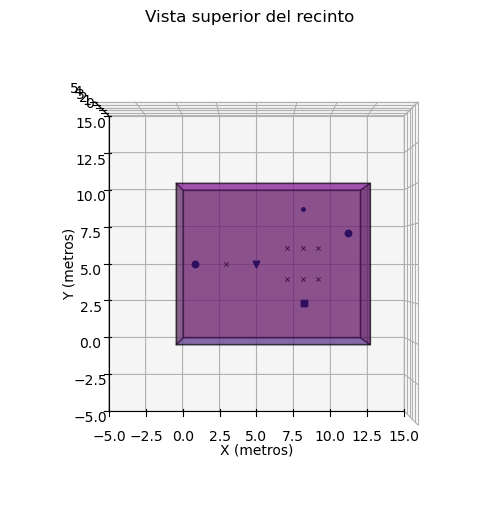

In [2]:
# Create a room
fs = 12000
room = pra.ShoeBox([12, 10, 5], fs=fs, max_order=0)

# Noise source
room.add_source([1, 5, 2.5])

# Reference microphones
room.add_microphone([3, 5, 2.5], fs=fs)

# Actuators
room.add_source([8, 2.5, 3.5])
room.add_source([5, 5, 2.5])
room.add_source([8, 8.5, 2.5])
room.add_source([11, 7, 1.5])

# Error microphones
room.add_microphone([7, 4, 2.5], fs=fs)
room.add_microphone([7, 6, 2.5], fs=fs)
room.add_microphone([8, 4, 2.5], fs=fs)
room.add_microphone([8, 6, 2.5], fs=fs)
room.add_microphone([9, 4, 2.5], fs=fs)
room.add_microphone([9, 6, 2.5], fs=fs)

fig, ax = room.plot()
ax.view_init(elev=90, azim=-90)
ax.set_title("Vista superior del recinto")
ax.set_xlim(-5, 15)
ax.set_ylim(-5, 15)
plt.grid(True)
plt.xlabel('X (metros)')
plt.ylabel('Y (metros)')
plt.show()

Obtain RIRs:

In [3]:
nReferenceMics = 1
nActuators = 4
nErrorMics = 6

room.compute_rir()
referencePaths = [room.rir[m][0] for m in range(nReferenceMics)]
primaryPaths = [room.rir[m][0] for m in range(nReferenceMics, nReferenceMics + nErrorMics)]
secondaryPaths = [[room.rir[m][s] for s in range(1, nActuators + 1)] for m in range(nReferenceMics, nReferenceMics + nErrorMics)]

# Shape RIRs for efficient convolution
referencePaths = np.array([
    np.pad(h, (0, max(len(h) for h in referencePaths) - len(h)))
    for h in referencePaths
])

primaryPaths = np.array([
    np.pad(h, (0, max(len(h) for h in primaryPaths) - len(h)))
    for h in primaryPaths
])

maxLen = max(len(h) for row in secondaryPaths for h in row)
secondaryPaths = np.array([
    [np.pad(h, (0, maxLen - len(h))) for h in row]
    for row in secondaryPaths
])

print("Reference paths shape: ", referencePaths.shape)
print("Primary paths shape: ", primaryPaths.shape)
print("Secondary paths shape: ", secondaryPaths.shape)

Reference paths shape:  (1, 152)
Primary paths shape:  (6, 365)
Secondary paths shape:  (6, 4, 261)


Algorithm:

/home/juana/miniconda3/envs/room-opt-complex/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


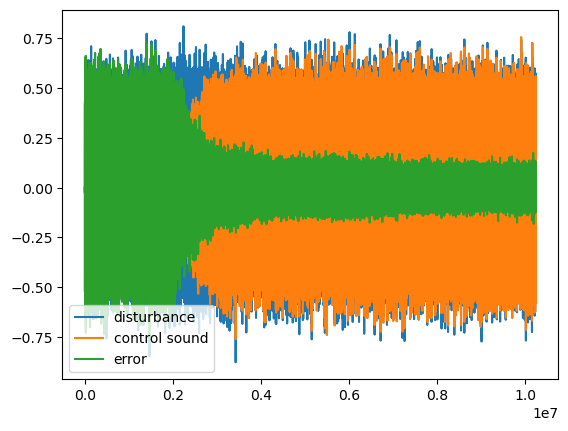

Noise reduction:  [-13.73010275 -12.86569362 -11.25442124 -12.67532363  -8.27832989
 -11.61471937]


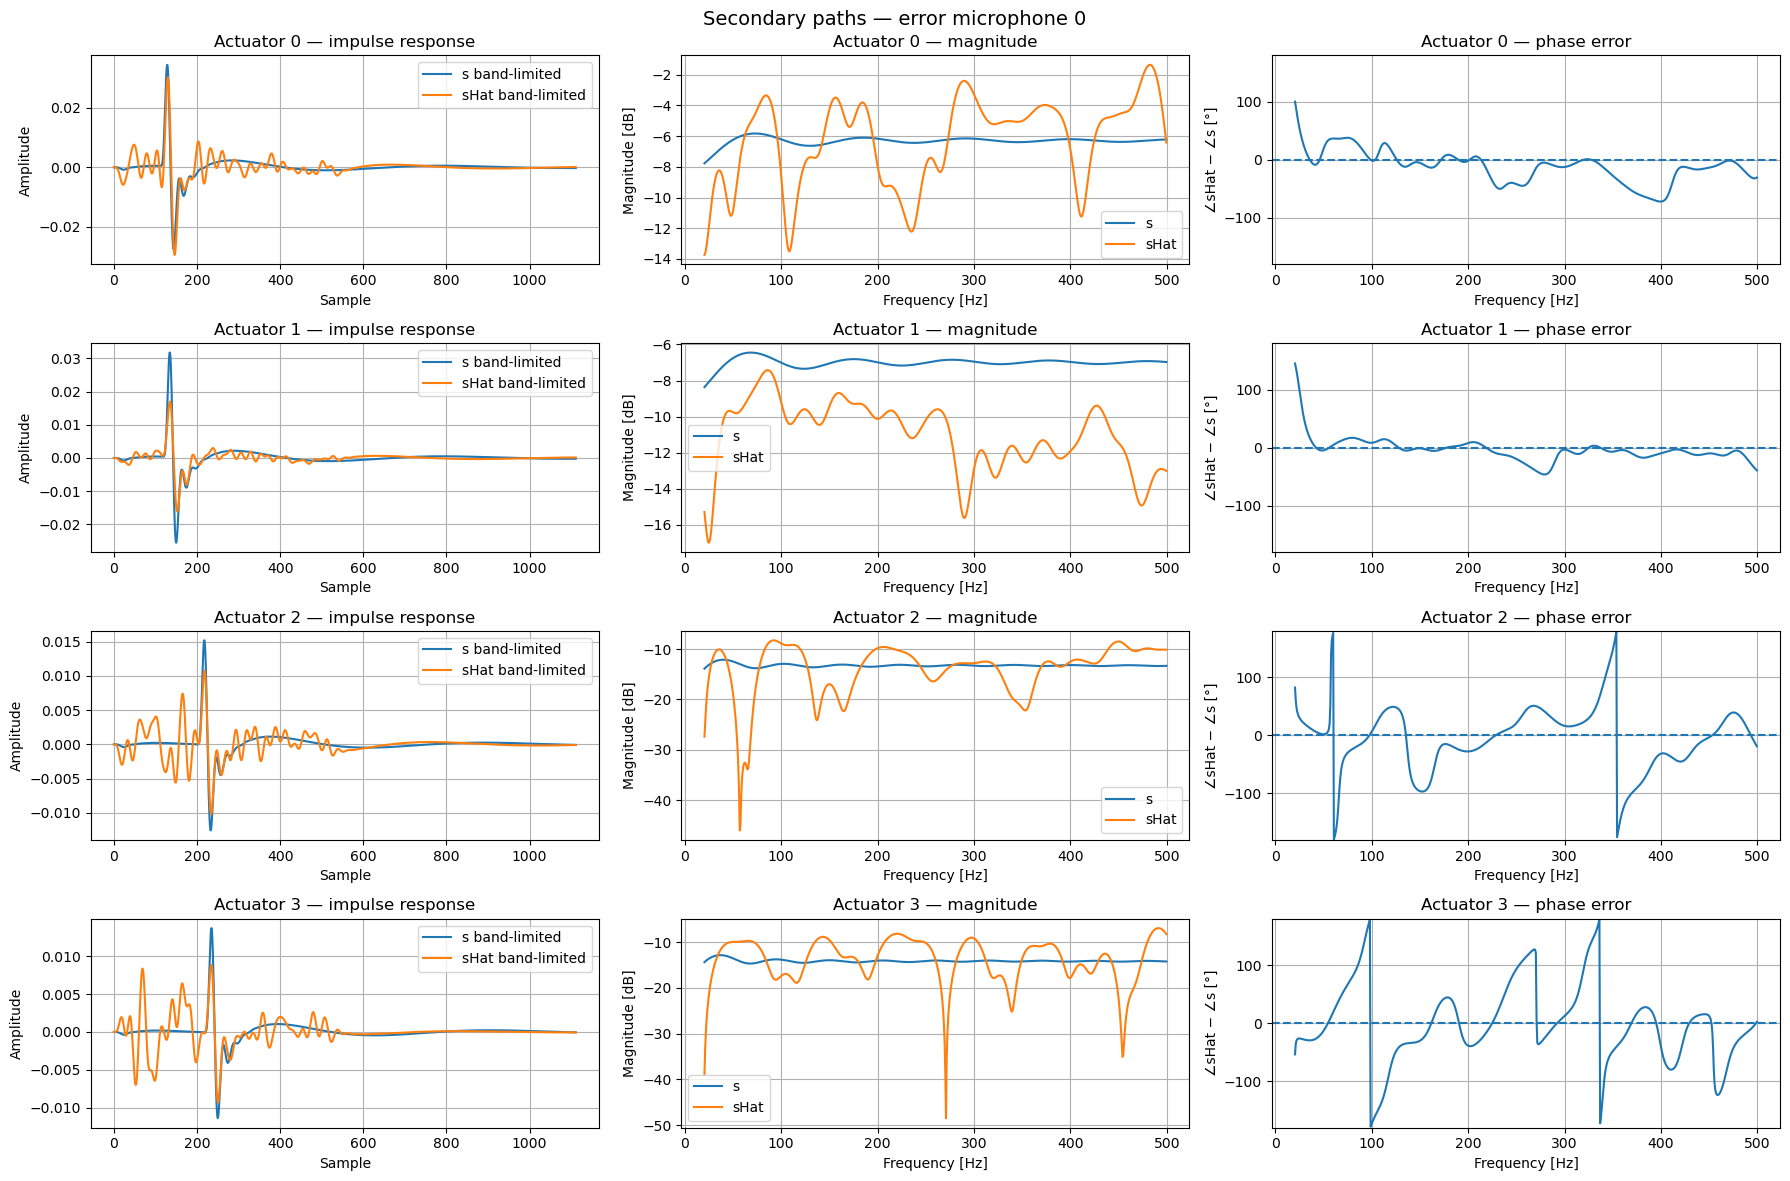

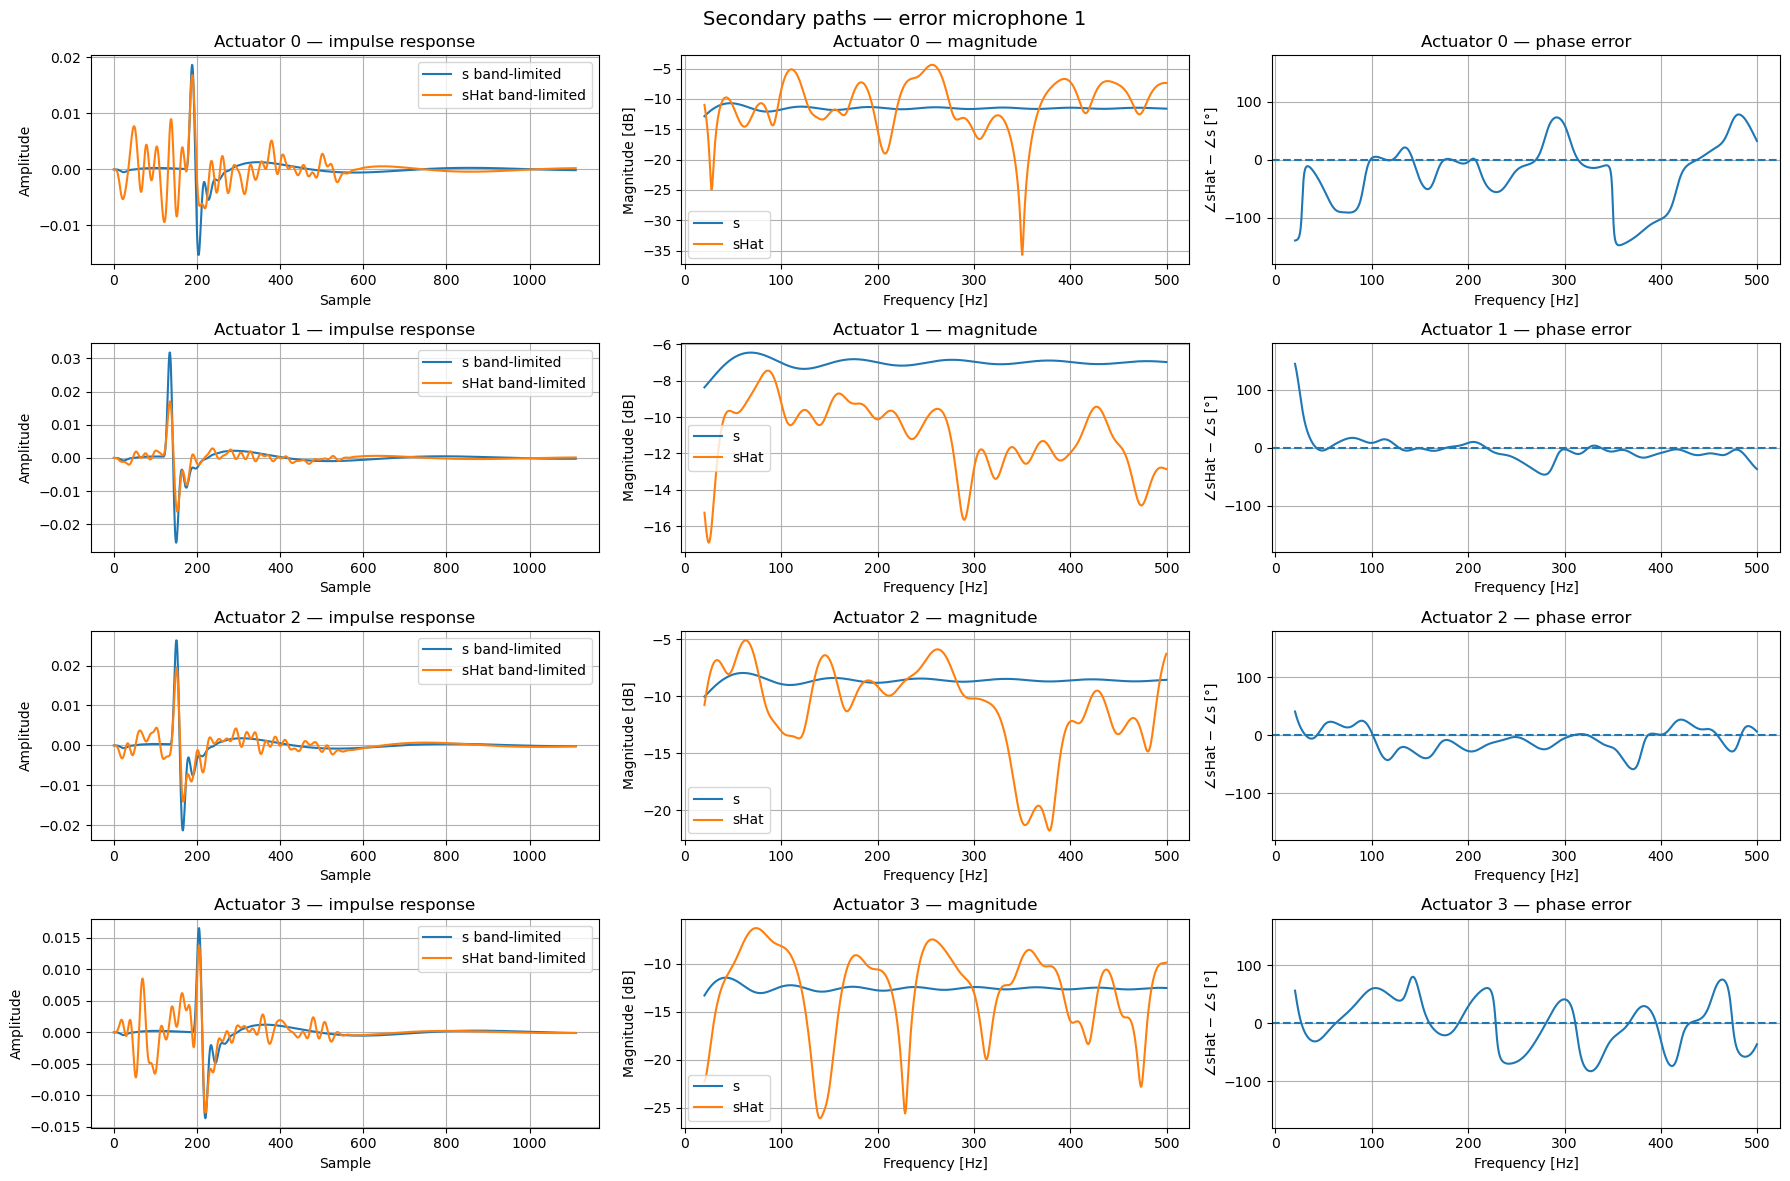

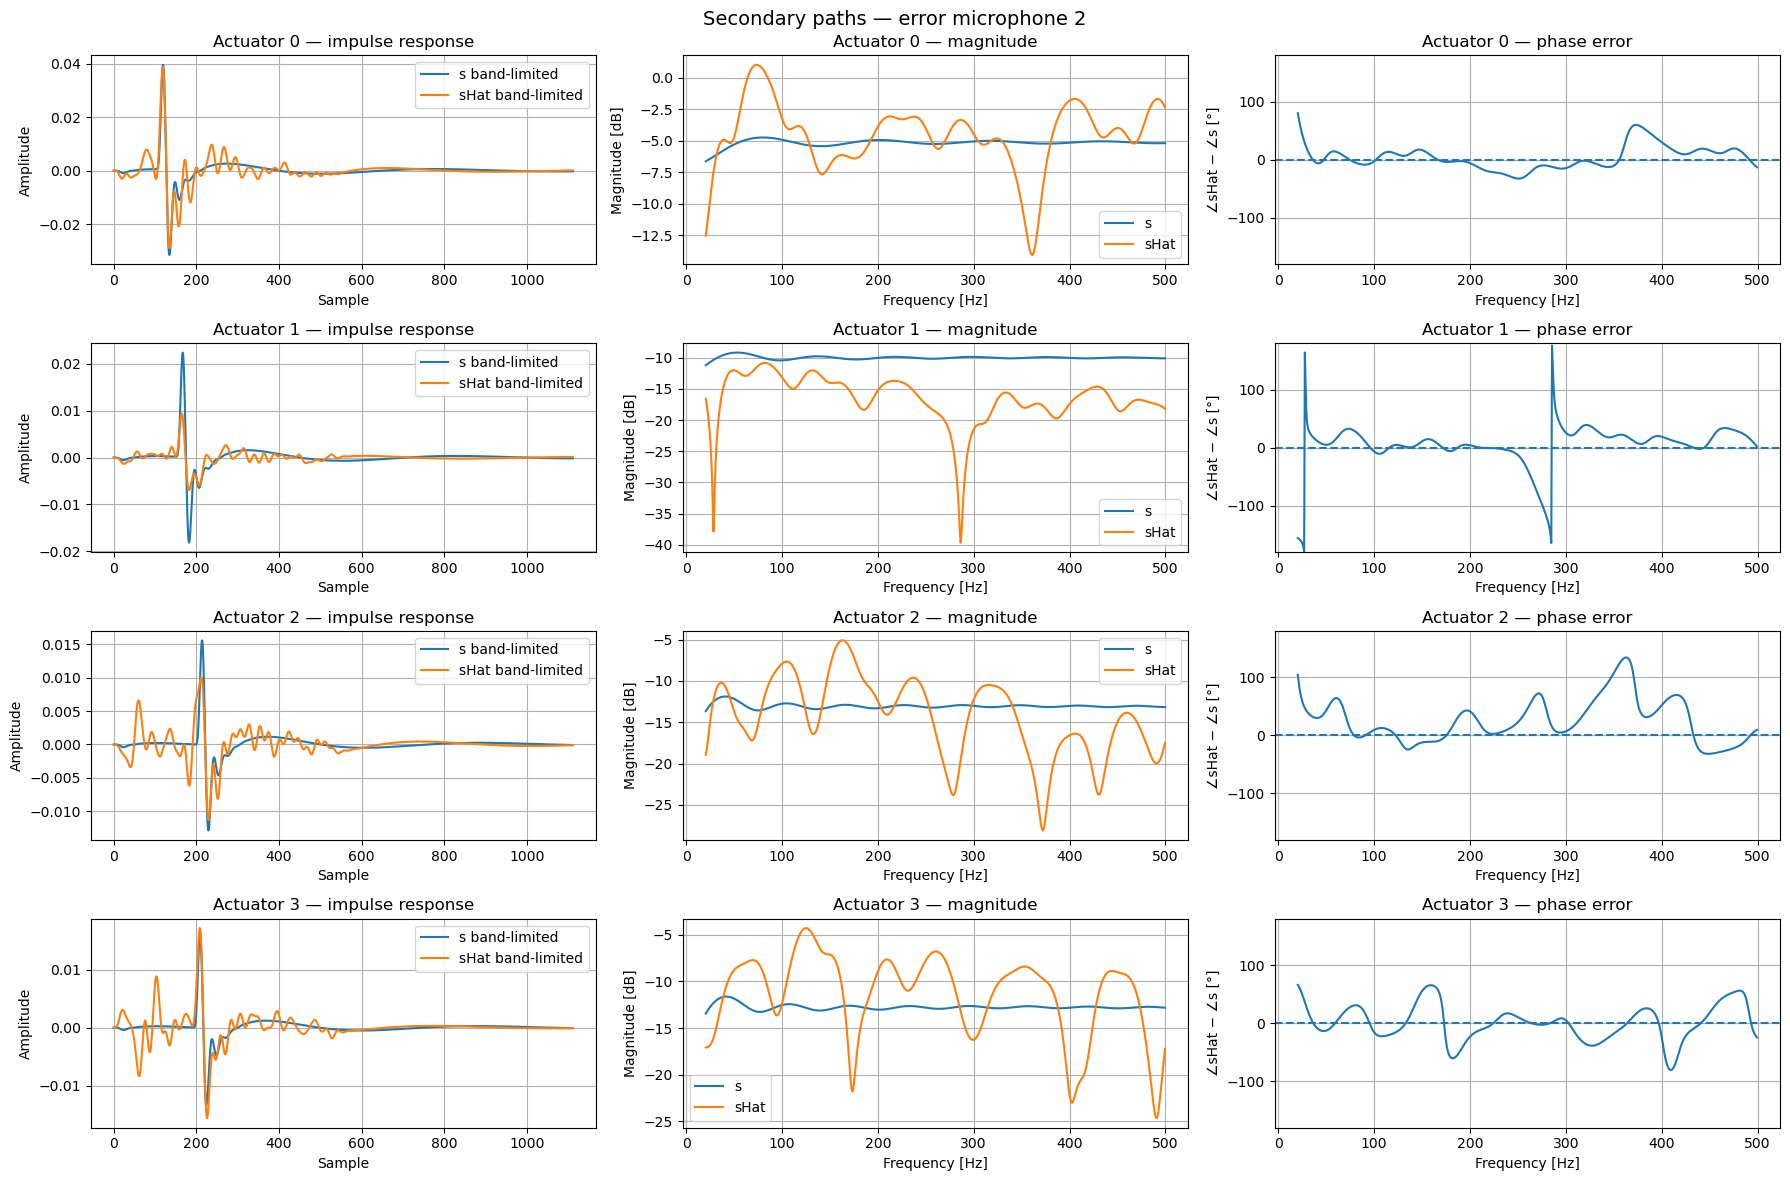

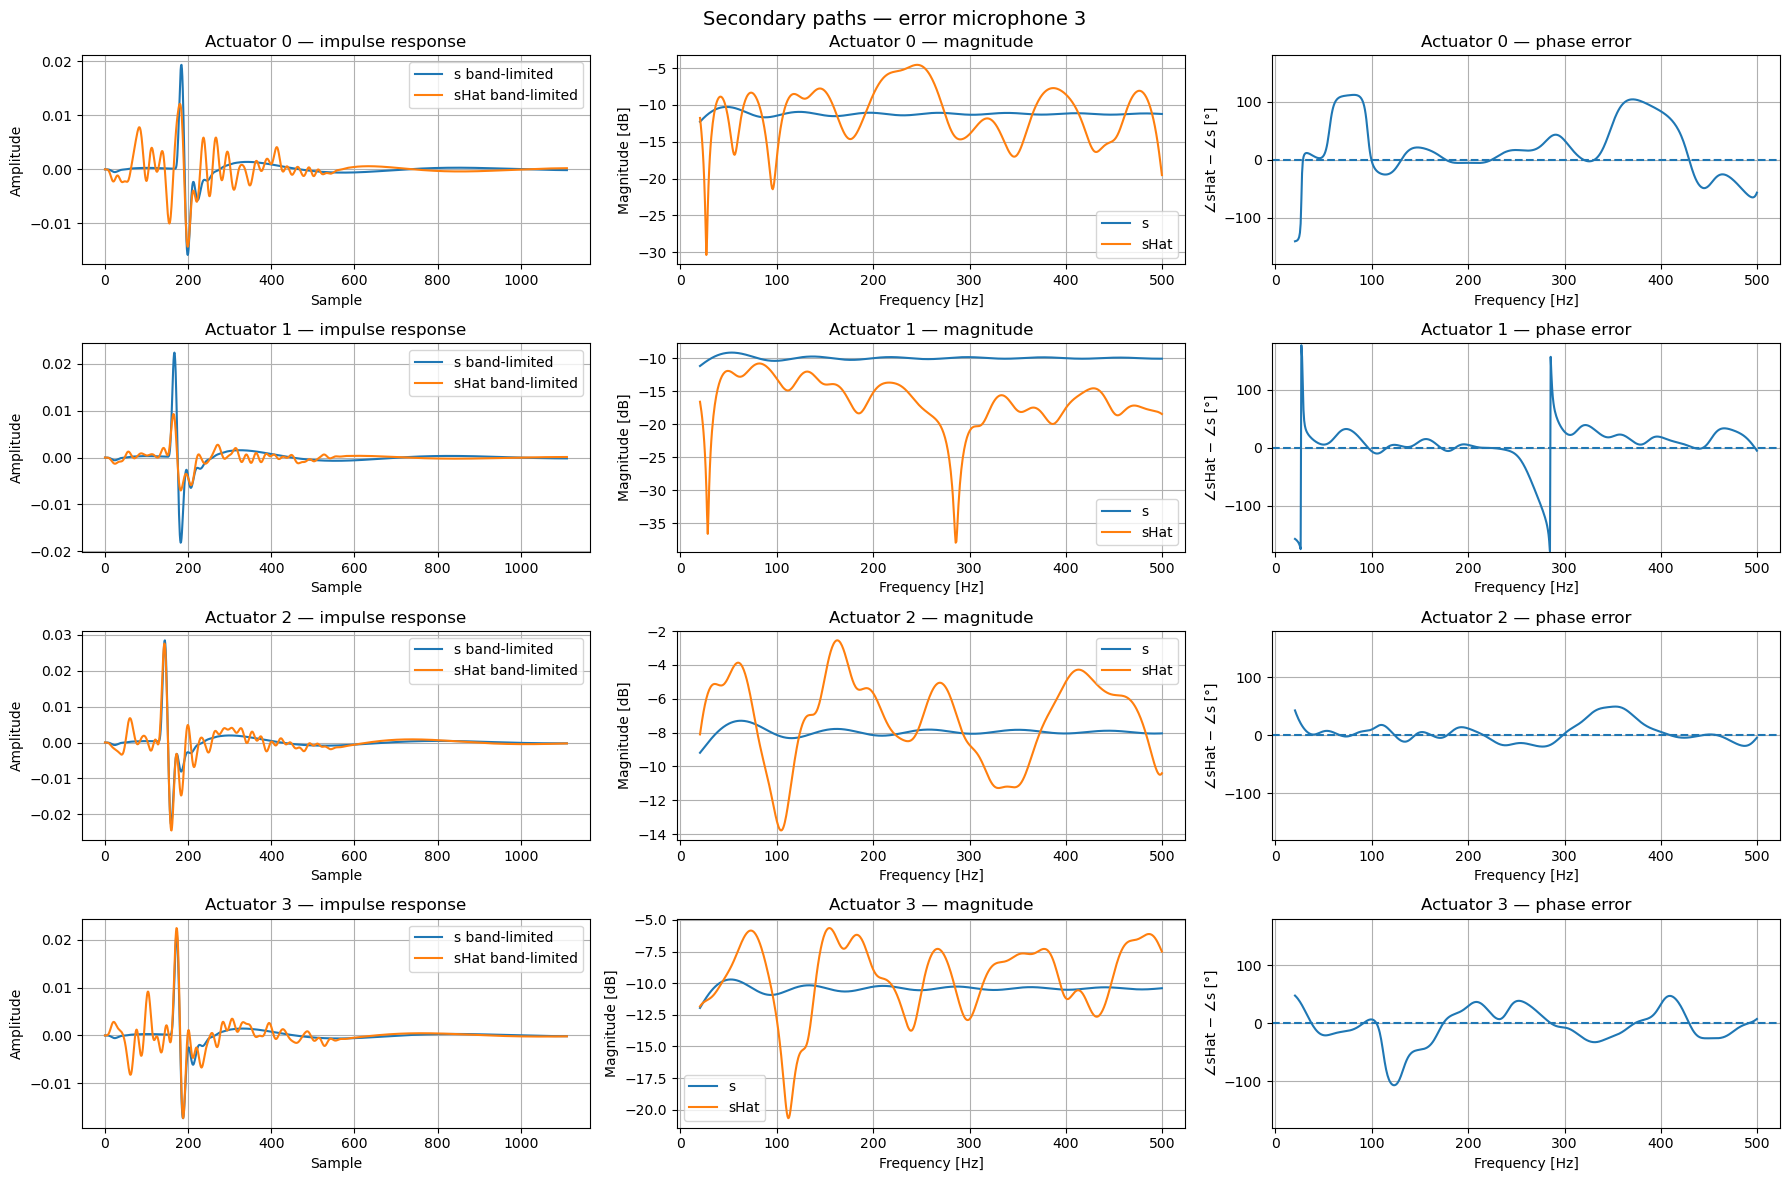

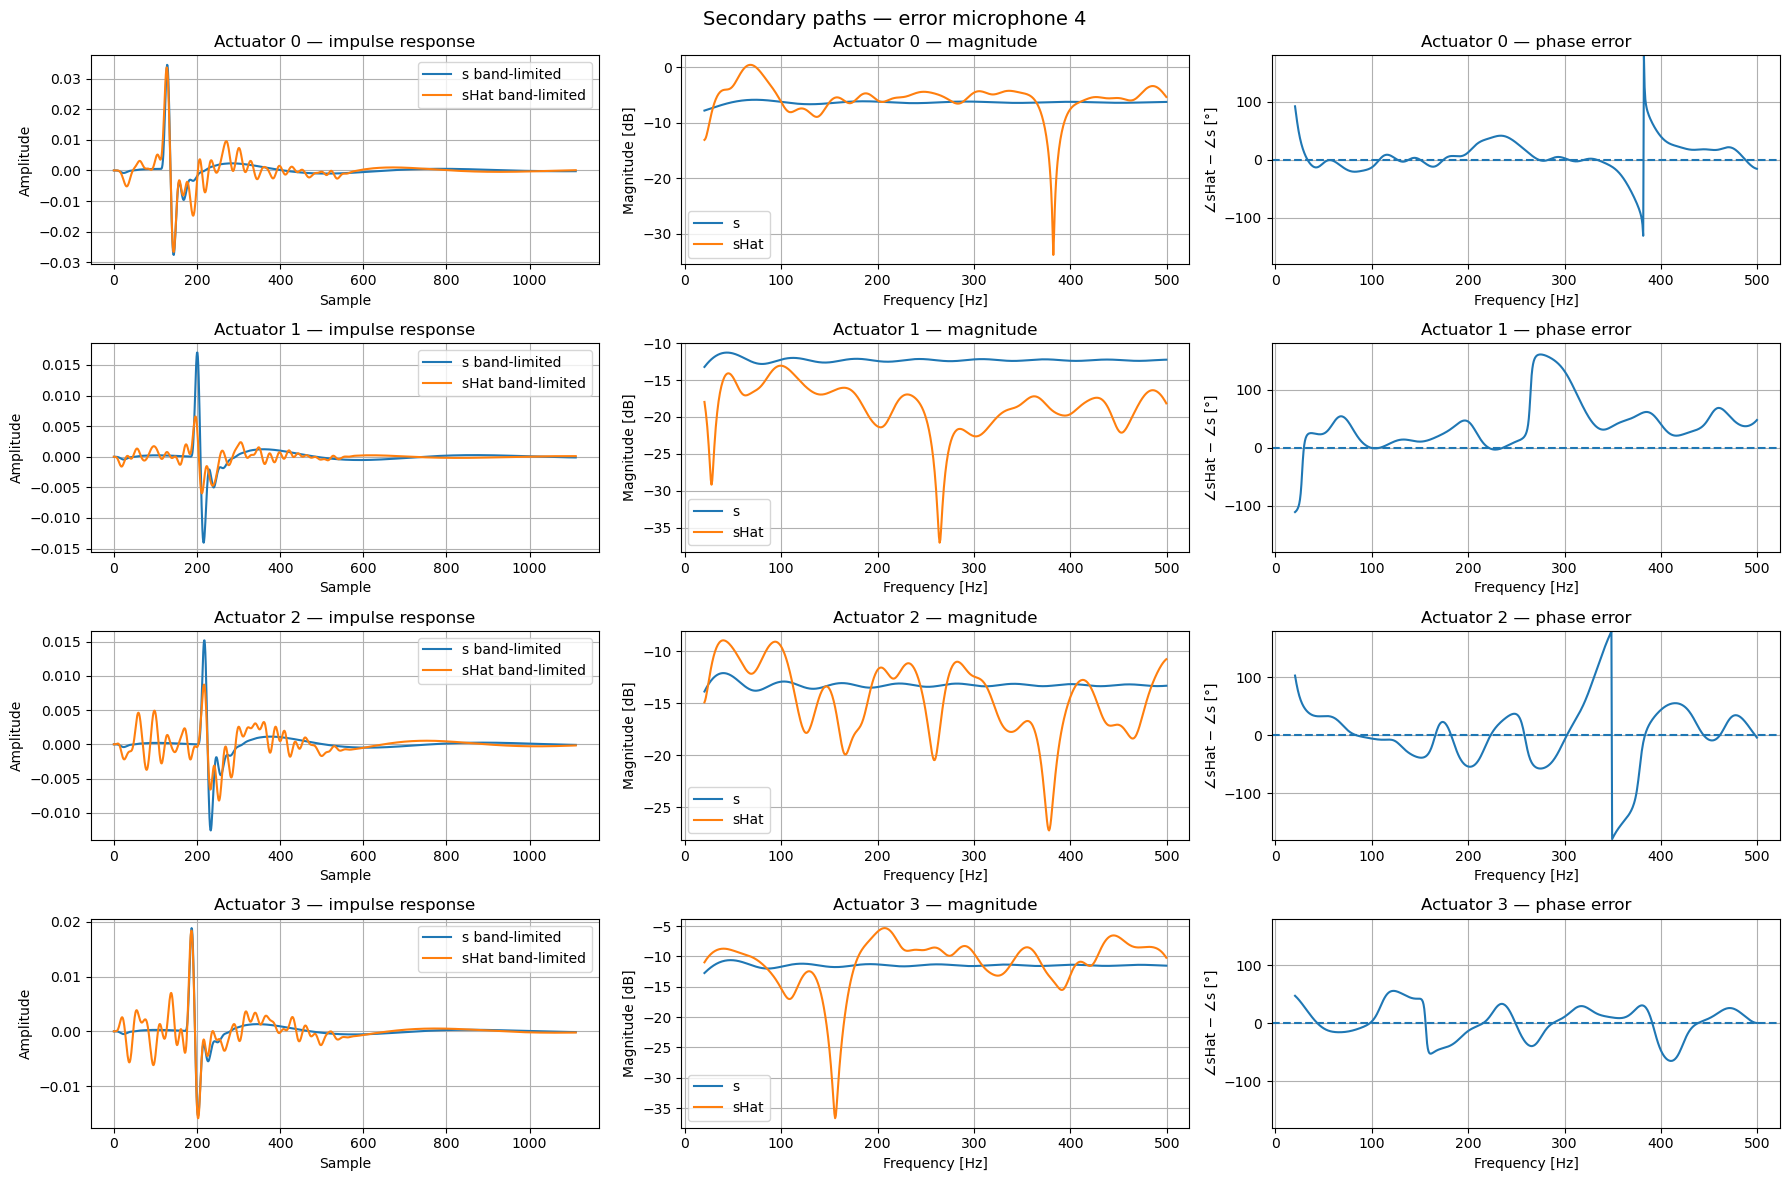

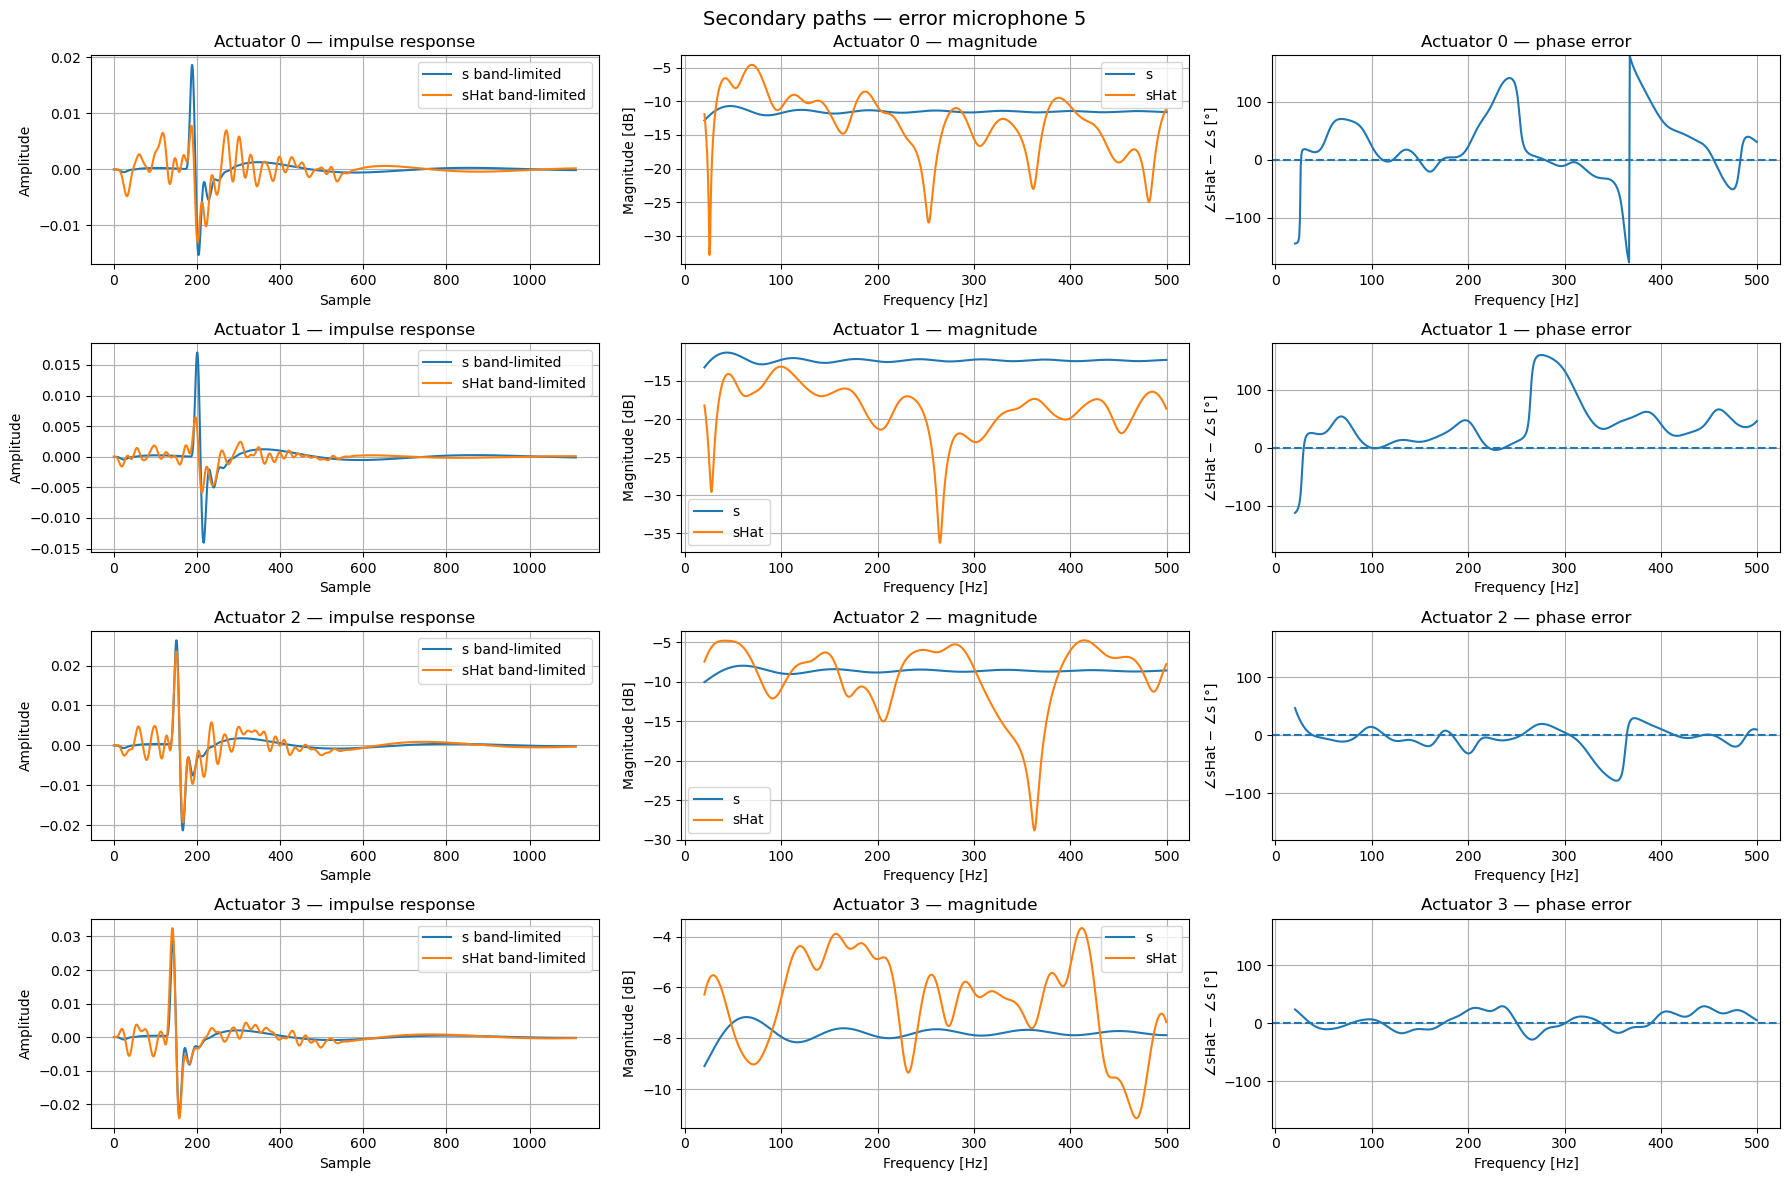

In [ ]:
# Disturbance
blocklength = 1024
nBlocks = 10000
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
whiteNoise = np.random.randn(N)
sos = butter(
    6,
    [20, 500],
    btype="bandpass",
    fs=fs,
    output="sos"
)
x = sosfilt(sos, whiteNoise)
x /= np.std(x) + 1e-12

# Adaptive filter matrix definition
nTaps = 512
wFilter = np.zeros((
    nActuators,
    nReferenceMics,
    nTaps
))
for nActuator in range(nActuators):
    wFilter[nActuator, 0, nActuator] = 0.01
mu = 0.01

# Primary paths model filter matrix definition
pHat = np.zeros((nErrorMics, nReferenceMics, nTaps))    # Has a different dimension from the real P(Z),
                                                        # since it has to be modelled from the reference signals,
                                                        # while the real P(Z) acts directly on the source.
muP = 0.0001

# Secondary paths model filter matrix definition
sHat = np.zeros((nErrorMics, nActuators, nTaps))
muS = 0.001

# States for online time domain convolution
rStates = np.zeros((nReferenceMics, referencePaths.shape[1] - 1))
pStates = np.zeros((nErrorMics, primaryPaths.shape[1] - 1))
wStates = np.zeros((nActuators, nReferenceMics, nTaps - 1))
sStates = np.zeros((nErrorMics, nActuators, secondaryPaths.shape[2] - 1))
sHatFXStates = np.zeros((nErrorMics, nActuators, nReferenceMics, nTaps - 1))    # State por generating the filtered reference
pHatStates = np.zeros((nErrorMics, nReferenceMics, nTaps - 1))
sHatSMCStates = np.zeros((nErrorMics, nActuators, nTaps - 1))                   # State for adapting the secondary path

# For testing
xRef = np.zeros((nReferenceMics, N))
d = np.zeros((nErrorMics, N))
u = np.zeros((nActuators, N))
y = np.zeros((nErrorMics, N))
e = np.zeros((nErrorMics, N))
mE = np.zeros((nErrorMics, N))

for k in range(nBlocks):
    # Block samples of X (simulation)
    xSignal = x[k*blocklength : (k+1)*blocklength]
    
    ################## Physical signals ##################

    # Reference signals (simulation)
    refSignals = np.zeros((nReferenceMics, blocklength))
    for m in range(nReferenceMics):
        refSignals[m], rStates[m] = lfilter(
            referencePaths[m],  
            [1],                
            xSignal,            
            zi=rStates[m]
        )
        
    # Disturbance signals (simulation)
    dSignals = np.zeros((nErrorMics, blocklength))
    for m in range(nErrorMics):
        dSignals[m], pStates[m] = lfilter(
            primaryPaths[m],
            [1],
            xSignal,            
            zi=pStates[m]
        )
        
    # Actuators signals
    wOutputSignals = np.zeros((nActuators, nReferenceMics, blocklength))
    for nActuator in range(nActuators):
        for nReference in range(nReferenceMics):
            wOutputSignals[nActuator][nReference], wStates[nActuator][nReference] = lfilter(
                wFilter[nActuator][nReference],
                [1],
                refSignals[nReference],
                zi=wStates[nActuator][nReference]
            )
    actuatorsSignals = np.sum(wOutputSignals, axis=1)        
    
    # Control and Errors signals (simulation)
    controlSignals = np.zeros((nErrorMics, nActuators, blocklength))
    for nError in range(nErrorMics):
        for nActuator in range(nActuators):
            controlSignals[nError][nActuator], sStates[nError][nActuator] = lfilter(
                secondaryPaths[nError][nActuator],
                [1],
                actuatorsSignals[nActuator],
                zi=sStates[nError][nActuator]
            )
    controlSignals = np.sum(controlSignals, axis=1)

    errorSignals = dSignals - controlSignals
    
    ################## Algorithm ##################

    # Compute the filtered reference matrix
    filteredReferences = np.zeros((nErrorMics, nActuators, nReferenceMics, blocklength))
    for nReferenceMic in range(nReferenceMics):
        for nActuator in range(nActuators):
            for nError in range(nErrorMics):
                filteredReferences[nError][nActuator][nReferenceMic], sHatFXStates[nError][nActuator][nReferenceMic] = lfilter(
                sHat[nError][nActuator],
                [1],
                refSignals[nReferenceMic],
                zi=sHatFXStates[nError][nActuator][nReferenceMic]
            )

    # LMS algorithm
    wFilter = adaptMultichannel(
        filteredReferences,
        errorSignals,
        nTaps,
        blocklength,
        wFilter,
        mu
    )

    # Filter the references by pHat
    pHatSignals = np.zeros((nErrorMics, nReferenceMics, blocklength))
    for nReferenceMic in range(nReferenceMics):
        for nError in range(nErrorMics):
            pHatSignals[nError][nReferenceMic], pHatStates[nError][nReferenceMic] = lfilter(
                pHat[nError][nReferenceMic],
                [1],
                refSignals[nReferenceMic],
                zi= pHatStates[nError][nReferenceMic]
            )
    pHatSignals = np.sum(pHatSignals, axis=1)

    # Filter the actuators signals by sHat
    sHatSignals = np.zeros((nErrorMics, nActuators, blocklength))
    for nActuator in range(nActuators):
        for nError in range(nErrorMics):
            sHatSignals[nError][nActuator], sHatSMCStates[nError][nActuator] = lfilter(
                sHat[nError][nActuator],
                [1],
                actuatorsSignals[nActuator],
                zi=sHatSMCStates[nError][nActuator]
            )
    sHatSignals = np.sum(sHatSignals, axis=1)

    # Compute the modelling error
    errorHatSignals = pHatSignals - sHatSignals
    modelingErrorSignals = errorSignals - errorHatSignals

    # Adapt pHat
    pHat = adaptPHat(
        refSignals,
        modelingErrorSignals,
        nTaps,
        blocklength,
        pHat,
        muP
    )

    # Adapt sHat
    sHat = adaptSHat(
        actuatorsSignals,
        modelingErrorSignals,
        nTaps,
        blocklength,
        sHat,
        muS
    )
    
    ################## For testing ##################
    start = k * blocklength
    end = (k + 1) * blocklength

    xRef[:, start:end] = refSignals
    d[:, start:end] = dSignals
    u[:, start:end] = actuatorsSignals
    y[:, start:end] = controlSignals
    e[:, start:end] = errorSignals
    mE[:, start:end] = modelingErrorSignals

plt.plot(d[0], label="disturbance")
plt.plot(y[0], label="control sound")
plt.plot(e[0], label="error")
#plt.plot(mE[0], label="modelling error")
plt.legend()
plt.show()

################## Post-algorithm analysis ##################

# 1. Noise reduction
steadySamples = 500 * blocklength

errorMse = np.mean(
    e[:, -steadySamples:] ** 2,
    axis=1
)

disturbanceMse = np.mean(
    d[:, -steadySamples:] ** 2,
    axis=1
)

reductionDb = 10 * np.log10(
    errorMse / disturbanceMse
)

print("Noise reduction: ", reductionDb)

# 2. Misalignment
from scipy.signal import freqz, sosfilt

lowFrequency = 20
highFrequency = 500
nFrequencies = 8192
epsilon = 1e-12

# Debe ser el mismo filtro usado para generar el ruido band-limited.
# Por ejemplo:
# sos = butter(
#     6,
#     [lowFrequency, highFrequency],
#     btype="bandpass",
#     fs=fs,
#     output="sos"
# )

for nError in range(nErrorMics):

    fig, axes = plt.subplots(
        nActuators,
        3,
        figsize=(18, 3 * nActuators),
        squeeze=False
    )

    fig.suptitle(
        f"Secondary paths — error microphone {nError}",
        fontsize=14
    )

    for nActuator in range(nActuators):

        sReal = secondaryPaths[nError, nActuator]
        sEstimated = sHat[nError, nActuator]

        # Igualar longitudes
        nCommonTaps = max(len(sReal), len(sEstimated))

        sRealPadded = np.pad(
            sReal,
            (0, nCommonTaps - len(sReal))
        )

        sEstimatedPadded = np.pad(
            sEstimated,
            (0, nCommonTaps - len(sEstimated))
        )

        # -------------------------------------------------
        # Respuestas impulsivas limitadas a la banda elegida
        # -------------------------------------------------

        # Agregamos ceros para observar la cola del pasa banda
        extraSamples = int(fs / lowFrequency)

        sRealExtended = np.pad(
            sRealPadded,
            (0, extraSamples)
        )

        sEstimatedExtended = np.pad(
            sEstimatedPadded,
            (0, extraSamples)
        )

        # Mismo filtro para ambas plantas
        sRealBand = sosfilt(sos, sRealExtended)
        sEstimatedBand = sosfilt(sos, sEstimatedExtended)

        axes[nActuator, 0].plot(
            sRealBand,
            label="s band-limited"
        )

        axes[nActuator, 0].plot(
            sEstimatedBand,
            label="sHat band-limited"
        )

        axes[nActuator, 0].set_title(
            f"Actuator {nActuator} — impulse response"
        )
        axes[nActuator, 0].set_xlabel("Sample")
        axes[nActuator, 0].set_ylabel("Amplitude")
        axes[nActuator, 0].grid()
        axes[nActuator, 0].legend()

        # ----------------------
        # Respuesta en frecuencia
        # ----------------------

        frequencies, sResponse = freqz(
            sRealPadded,
            worN=nFrequencies,
            fs=fs
        )

        _, sHatResponse = freqz(
            sEstimatedPadded,
            worN=nFrequencies,
            fs=fs
        )

        bandMask = (
            (frequencies >= lowFrequency)
            & (frequencies <= highFrequency)
        )

        # Magnitud
        sMagnitudeDb = 20 * np.log10(
            np.abs(sResponse) + epsilon
        )

        sHatMagnitudeDb = 20 * np.log10(
            np.abs(sHatResponse) + epsilon
        )

        axes[nActuator, 1].plot(
            frequencies[bandMask],
            sMagnitudeDb[bandMask],
            label="s"
        )

        axes[nActuator, 1].plot(
            frequencies[bandMask],
            sHatMagnitudeDb[bandMask],
            label="sHat"
        )

        axes[nActuator, 1].set_title(
            f"Actuator {nActuator} — magnitude"
        )
        axes[nActuator, 1].set_xlabel("Frequency [Hz]")
        axes[nActuator, 1].set_ylabel("Magnitude [dB]")
        axes[nActuator, 1].grid()
        axes[nActuator, 1].legend()

        # Error relativo de fase
        phaseError = np.angle(
            sHatResponse * np.conj(sResponse),
            deg=True
        )

        axes[nActuator, 2].plot(
            frequencies[bandMask],
            phaseError[bandMask]
        )

        axes[nActuator, 2].axhline(
            0,
            linestyle="--"
        )

        axes[nActuator, 2].set_ylim(-180, 180)
        axes[nActuator, 2].set_title(
            f"Actuator {nActuator} — phase error"
        )
        axes[nActuator, 2].set_xlabel("Frequency [Hz]")
        axes[nActuator, 2].set_ylabel(
            "∠sHat − ∠s [°]"
        )
        axes[nActuator, 2].grid()

    plt.tight_layout()
    plt.show()


